# BACE Full Benchmark (5 Seeds)

This notebook benchmarks classical, uni-modal, bi-modal, and tri-modal models on BACE with DeepChem MolNet scaffold split and five random seeds.

Compared model families include RF (RDKit), ChebNet, SEG, TAME (tri-modal TAME-style), and TAME-Fusion (SEG-fusion + descriptor-aware 2-gate MoE), each with vanilla and stage-1-pretrained variants where applicable.

## Setup
- Dataset: BACE-1 inhibitor classification (DeepChem MolNet)
- Split: DeepChem scaffold split (predefined train/valid/test)
- Seeds: `[11, 22, 33, 44, 55]`
- Metric report: ROC-AUC, Accuracy, F1

In [1]:
import sys
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import deepchem as dc

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def _to_1d(x):
    return np.asarray(x, dtype=np.float32).reshape(-1)

def classification_metrics(y_true, y_proba, threshold=0.5, weights=None):
    yt = _to_1d(y_true)
    yp = np.clip(_to_1d(y_proba), 0.0, 1.0)

    mask = np.isfinite(yt) & np.isfinite(yp)
    if weights is not None:
        w = _to_1d(weights)
        mask = mask & (w > 0)

    if int(mask.sum()) == 0:
        return {'roc_auc': np.nan, 'accuracy': np.nan, 'f1': np.nan, 'n_eval': 0}

    yt = yt[mask]
    yp = yp[mask]
    yhat = (yp >= float(threshold)).astype(np.float32)

    if np.unique(yt).size >= 2:
        roc_auc = float(roc_auc_score(yt, yp))
    else:
        roc_auc = np.nan

    acc = float(accuracy_score(yt, yhat))
    f1 = float(f1_score(yt, yhat, zero_division=0))
    return {'roc_auc': roc_auc, 'accuracy': acc, 'f1': f1, 'n_eval': int(mask.sum())}

def find_best_threshold(y_true, y_proba, weights=None):
    yt = _to_1d(y_true)
    yp = np.clip(_to_1d(y_proba), 0.0, 1.0)
    mask = np.isfinite(yt) & np.isfinite(yp)
    if weights is not None:
        w = _to_1d(weights)
        mask = mask & (w > 0)

    yt = yt[mask]
    yp = yp[mask]
    if yt.size == 0:
        return 0.5

    thresholds = np.linspace(0.05, 0.95, 91, dtype=np.float32)
    best_thr = 0.5
    best_f1 = -1.0
    for t in thresholds:
        yhat = (yp >= t).astype(np.float32)
        f1 = float(f1_score(yt, yhat, zero_division=0))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(t)
    return best_thr

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)

    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue

        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))

    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(np.asarray(train_X, dtype=np.float32), axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

@contextmanager
def patch_build_model_with_encoder_init(predictor, encoder_state, strict=True):
    original_build_model = predictor._build_model

    def _patched_build_model(*args, **kwargs):
        result = original_build_model(*args, **kwargs)
        if getattr(predictor, '_encoder', None) is None:
            raise RuntimeError('Predictor encoder is not initialized after _build_model()')
        predictor._encoder.load_state_dict(encoder_state, strict=strict)
        return result

    predictor._build_model = _patched_build_model
    try:
        yield
    finally:
        predictor._build_model = original_build_model

In [3]:
# Benchmark seeds
SEEDS = [11, 22, 33, 44, 55]

# Use DeepChem MolNet predefined scaffold split directly
tasks, datasets, _ = dc.molnet.load_bace_classification(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

y_train_raw = np.asarray(train_dc.y, dtype=np.float32).reshape(-1)
y_valid_raw = np.asarray(valid_dc.y, dtype=np.float32).reshape(-1)
y_test_raw = np.asarray(test_dc.y, dtype=np.float32).reshape(-1)

w_train = np.asarray(train_dc.w, dtype=np.float32).reshape(-1)
w_valid = np.asarray(valid_dc.w, dtype=np.float32).reshape(-1)
w_test = np.asarray(test_dc.w, dtype=np.float32).reshape(-1)

# Load text embeddings once
emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'binding_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = np.asarray(all_emb[:n_train], dtype=np.float32)
valid_emb = np.asarray(all_emb[n_train:n_train + n_valid], dtype=np.float32)
test_emb = np.asarray(all_emb[n_train + n_valid:], dtype=np.float32)
text_dim = int(all_emb.shape[1])

# Descriptors for TAME and RF (RDKit only)
rd_train, rd_names = rdkit_descriptor_matrix(train_smiles)
rd_valid, _ = rdkit_descriptor_matrix(valid_smiles)
rd_test, _ = rdkit_descriptor_matrix(test_smiles)
rd_train, rd_valid, rd_test = impute_with_train_median(rd_train, rd_valid, rd_test)

rf_train_X = rd_train
rf_valid_X = rd_valid
rf_test_X = rd_test

print(f'BACE size: {len(train_smiles) + len(valid_smiles) + len(test_smiles)}')
print(f'DeepChem scaffold split sizes: train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Class ratio train (positives): {float(np.mean(y_train_raw[w_train > 0])):.3f}')
print(f'Text dim: {text_dim}')
print(f'RDKit descriptor dim: {rd_train.shape[1]}')
print(f'RF descriptor dim (RDKit only): {rf_train_X.shape[1]}')


Loading embeddings from binding_fast_text_embeddings_compact.npz...
  Loaded 1513 entries, dim=3072
  Memory mode: mapped
BACE size: 1513
DeepChem scaffold split sizes: train=1210, val=151, test=152
Class ratio train (positives): 0.426
Text dim: 3072
RDKit descriptor dim: 217
RF descriptor dim (RDKit only): 217


In [4]:
CHEB_FIT_KWARGS = {
    'num_epochs': 140,
    'batch_size': 64,
    'learning_rate': 5e-4,
    'weight_decay': 1e-2,
    'patience': 20,
}

SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': True,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.3,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 5e-4,
    'weight_decay': 1e-2,
    'batch_size': 32,
    'num_epochs': 140,
    'patience': 25,
    'scheduler': 'plateau',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

TAME_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 5e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 15,
}

TAME_FUSION_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'fusion_dropout': 0.30,
    'moe_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 5e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 15,
}

BACKBONE_ARCH = {
    'hidden_channels': SEG_FIT_KWARGS['hidden_channels'],
    'num_layers': SEG_FIT_KWARGS['num_layers'],
    'K': SEG_FIT_KWARGS['K'],
    'pool': SEG_FIT_KWARGS['pool'],
}

def make_cheb_config():
    return ChebPredictorConfig(
        task='classification',
        hidden_channels=BACKBONE_ARCH['hidden_channels'],
        K=BACKBONE_ARCH['K'],
        num_layers=BACKBONE_ARCH['num_layers'],
        dropout=0.2,
        pool=BACKBONE_ARCH['pool'],
        set2set_processing_steps=6,
        add_hydrogens=False,
        head_hidden_dim=64,
        head_dropout=0.2,
    )

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='classification',
        num_tasks=1,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
        add_hydrogens=False,
    )

def make_tame_config(text_embedding_dim):
    return TAMEPredictorConfig(
        task='classification',
        num_tasks=1,
        hidden_channels=TAME_FIT_KWARGS['hidden_channels'],
        K=TAME_FIT_KWARGS['K'],
        num_layers=TAME_FIT_KWARGS['num_layers'],
        pool=TAME_FIT_KWARGS['pool'],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=TAME_FIT_KWARGS['fusion_hidden_dim'],
        projection_dropout=TAME_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def make_tame_fusion_config(text_embedding_dim):
    return TAMEFusionPredictorConfig(
        task='classification',
        num_tasks=1,
        hidden_channels=TAME_FUSION_FIT_KWARGS['hidden_channels'],
        K=TAME_FUSION_FIT_KWARGS['K'],
        num_layers=TAME_FUSION_FIT_KWARGS['num_layers'],
        pool=TAME_FUSION_FIT_KWARGS['pool'],
        set2set_processing_steps=TAME_FUSION_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        fusion=TAME_FUSION_FIT_KWARGS['fusion'],
        fusion_dim=TAME_FUSION_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=TAME_FUSION_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=TAME_FUSION_FIT_KWARGS['fusion_dropout'],
        moe_hidden_dim=TAME_FUSION_FIT_KWARGS['moe_hidden_dim'],
        projection_dropout=TAME_FUSION_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FUSION_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FUSION_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FUSION_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FUSION_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FUSION_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FUSION_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def _arch_from_encoder_state(encoder_state):
    layer_ids = sorted({
        int(k.split('.')[1])
        for k in encoder_state.keys()
        if k.startswith('layers.') and k.endswith('.weight')
    })
    if not layer_ids:
        raise RuntimeError('No encoder layer weights found in encoder_state.')

    first_weight_key = f'layers.{layer_ids[0]}.weight'
    first_weight = encoder_state[first_weight_key]
    if first_weight.ndim != 3:
        raise RuntimeError(
            f'Unexpected encoder weight shape for {first_weight_key}: {tuple(first_weight.shape)}'
        )

    return {
        'K': int(first_weight.shape[0]),
        'hidden_channels': int(first_weight.shape[-1]),
        'num_layers': int(max(layer_ids) + 1),
    }

def resolve_pretrain_checkpoint(pretrain_stage, *, hidden_channels, num_layers, K, pool):
    stage_cfg = {
        'stage1_node': {'pattern_prefix': 'cheb_foundation_stage1'},
        'stage2_descriptor': {'pattern_prefix': 'cheb_foundation_2stage'},
    }
    if pretrain_stage not in stage_cfg:
        raise ValueError(f'Unsupported pretrain_stage={pretrain_stage!r}')

    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    pattern_prefix = stage_cfg[pretrain_stage]['pattern_prefix']
    pattern = f"{pattern_prefix}__h{int(hidden_channels)}__L{int(num_layers)}__K{int(K)}__pool-{pool}__*.pt"
    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime, reverse=True
    )
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint found for stage={pretrain_stage!r} with required pattern={pattern!r}."
        )
    return candidates[0]

def load_pretrained_encoder_state(ckpt_path, expected_stage, expected_arch):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != expected_stage:
        raise RuntimeError(
            f"Expected checkpoint with pretraining_stage={expected_stage!r}, got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    arch = _arch_from_encoder_state(enc_state)
    for k in ('hidden_channels', 'K', 'num_layers'):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(
                f"Checkpoint architecture mismatch for {Path(ckpt_path).name}: {k}={arch[k]} but expected {expected_arch[k]}"
            )

    print(f'Loaded {expected_stage} encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

CHEB_ENCODER_ARCH = dict(BACKBONE_ARCH)
SEG_ENCODER_ARCH = {
    'hidden_channels': SEG_FIT_KWARGS['hidden_channels'],
    'num_layers': SEG_FIT_KWARGS['num_layers'],
    'K': SEG_FIT_KWARGS['K'],
    'pool': SEG_FIT_KWARGS['pool'],
}
TAME_ENCODER_ARCH = {
    'hidden_channels': TAME_FIT_KWARGS['hidden_channels'],
    'num_layers': TAME_FIT_KWARGS['num_layers'],
    'K': TAME_FIT_KWARGS['K'],
    'pool': TAME_FIT_KWARGS['pool'],
}
TAME_FUSION_ENCODER_ARCH = {
    'hidden_channels': TAME_FUSION_FIT_KWARGS['hidden_channels'],
    'num_layers': TAME_FUSION_FIT_KWARGS['num_layers'],
    'K': TAME_FUSION_FIT_KWARGS['K'],
    'pool': TAME_FUSION_FIT_KWARGS['pool'],
}

stage1_cheb_ckpt = resolve_pretrain_checkpoint('stage1_node', **CHEB_ENCODER_ARCH)
stage1_seg_ckpt = resolve_pretrain_checkpoint('stage1_node', **SEG_ENCODER_ARCH)
stage1_tame_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_ENCODER_ARCH)
stage1_tame_fusion_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_FUSION_ENCODER_ARCH)

stage1_cheb_encoder_state = load_pretrained_encoder_state(stage1_cheb_ckpt, 'stage1_node', CHEB_ENCODER_ARCH)
stage1_seg_encoder_state = load_pretrained_encoder_state(stage1_seg_ckpt, 'stage1_node', SEG_ENCODER_ARCH)
stage1_tame_encoder_state = load_pretrained_encoder_state(stage1_tame_ckpt, 'stage1_node', TAME_ENCODER_ARCH)
stage1_tame_fusion_encoder_state = load_pretrained_encoder_state(stage1_tame_fusion_ckpt, 'stage1_node', TAME_FUSION_ENCODER_ARCH)

Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt


In [5]:
def run_rf(seed):
    rf = RandomForestClassifier(
        n_estimators=800,
        max_features='sqrt',
        min_samples_leaf=1,
        random_state=int(seed),
        n_jobs=-1,
    )
    rf.fit(rf_train_X, y_train_raw)
    valid_proba = rf.predict_proba(rf_valid_X)[:, 1]
    test_proba = rf.predict_proba(rf_test_X)[:, 1]

    thr = find_best_threshold(y_valid_raw, valid_proba, weights=w_valid)
    m = classification_metrics(y_test_raw, test_proba, threshold=thr, weights=w_test)
    m['model'] = 'RF_RDKit'
    m['seed'] = int(seed)
    m['threshold'] = float(thr)
    return m

def run_cheb(seed, encoder_init_state=None, label='CHEBNET_VANILLA'):
    cheb = ChebPredictor(config=make_cheb_config(), device=str(device))

    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        num_epochs=CHEB_FIT_KWARGS['num_epochs'],
        batch_size=CHEB_FIT_KWARGS['batch_size'],
        learning_rate=CHEB_FIT_KWARGS['learning_rate'],
        weight_decay=CHEB_FIT_KWARGS['weight_decay'],
        patience=CHEB_FIT_KWARGS['patience'],
        verbose=False,
        seed=int(seed),
    )

    if encoder_init_state is None:
        hist = cheb.fit(**fit_kwargs)
    else:
        with patch_build_model_with_encoder_init(cheb, encoder_init_state, strict=True):
            hist = cheb.fit(**fit_kwargs)

    valid_proba = np.asarray(cheb.predict_batch(valid_smiles, batch_size=128), dtype=np.float32).reshape(-1)
    test_proba = np.asarray(cheb.predict_batch(test_smiles, batch_size=128), dtype=np.float32).reshape(-1)
    thr = find_best_threshold(y_valid_raw, valid_proba, weights=w_valid)

    m = classification_metrics(y_test_raw, test_proba, threshold=thr, weights=w_test)
    m['model'] = label
    m['seed'] = int(seed)
    m['threshold'] = float(thr)
    return m, hist

def run_seg(seed, encoder_init_state=None, label='SEG_VANILLA'):
    seg = SEGPredictor(config=make_seg_config(text_dim), device=str(device))

    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        num_epochs=SEG_FIT_KWARGS['num_epochs'],
        batch_size=SEG_FIT_KWARGS['batch_size'],
        learning_rate=SEG_FIT_KWARGS['learning_rate'],
        weight_decay=SEG_FIT_KWARGS['weight_decay'],
        patience=SEG_FIT_KWARGS['patience'],
        scheduler=SEG_FIT_KWARGS['scheduler'],
        scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
        scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
        min_lr=SEG_FIT_KWARGS['min_lr'],
        grad_clip=SEG_FIT_KWARGS['grad_clip'],
        verbose=False,
        seed=int(seed),
    )

    if encoder_init_state is None:
        hist = seg.fit(**fit_kwargs)
    else:
        with patch_build_model_with_encoder_init(seg, encoder_init_state, strict=True):
            hist = seg.fit(**fit_kwargs)

    valid_proba = np.asarray(seg.predict_batch(valid_smiles, text_embeddings=valid_emb), dtype=np.float32).reshape(-1)
    test_proba = np.asarray(seg.predict_batch(test_smiles, text_embeddings=test_emb), dtype=np.float32).reshape(-1)
    thr = find_best_threshold(y_valid_raw, valid_proba, weights=w_valid)

    m = classification_metrics(y_test_raw, test_proba, threshold=thr, weights=w_test)
    m['model'] = label
    m['seed'] = int(seed)
    m['threshold'] = float(thr)
    return m, hist

def run_tame(seed, encoder_init_state=None, label='TAME_VANILLA'):
    tame = TAMEPredictor(config=make_tame_config(text_dim), device=str(device))

    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        descriptor_features=rd_train,
        val_descriptor_features=rd_valid,
        num_epochs=TAME_FIT_KWARGS['num_epochs'],
        batch_size=TAME_FIT_KWARGS['batch_size'],
        learning_rate=TAME_FIT_KWARGS['learning_rate'],
        weight_decay=TAME_FIT_KWARGS['weight_decay'],
        patience=TAME_FIT_KWARGS['patience'],
        verbose=False,
        seed=int(seed),
    )

    if encoder_init_state is not None:
        fit_kwargs['init_encoder_state'] = encoder_init_state

    hist = tame.fit(**fit_kwargs)

    valid_proba = np.asarray(
        tame.predict_batch(valid_smiles, text_embeddings=valid_emb, descriptor_features=rd_valid, batch_size=TAME_FIT_KWARGS['batch_size']),
        dtype=np.float32,
    ).reshape(-1)
    test_proba = np.asarray(
        tame.predict_batch(test_smiles, text_embeddings=test_emb, descriptor_features=rd_test, batch_size=TAME_FIT_KWARGS['batch_size']),
        dtype=np.float32,
    ).reshape(-1)
    thr = find_best_threshold(y_valid_raw, valid_proba, weights=w_valid)

    m = classification_metrics(y_test_raw, test_proba, threshold=thr, weights=w_test)
    m['model'] = label
    m['seed'] = int(seed)
    m['threshold'] = float(thr)
    return m, hist

def run_tame_fusion(seed, encoder_init_state=None, label='TAME_FUSION_VANILLA'):
    tame_fusion = TAMEFusionPredictor(config=make_tame_fusion_config(text_dim), device=str(device))

    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=y_train_raw.tolist(),
        val_smiles=valid_smiles,
        val_labels=y_valid_raw.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        descriptor_features=rd_train,
        val_descriptor_features=rd_valid,
        num_epochs=TAME_FUSION_FIT_KWARGS['num_epochs'],
        batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
        learning_rate=TAME_FUSION_FIT_KWARGS['learning_rate'],
        weight_decay=TAME_FUSION_FIT_KWARGS['weight_decay'],
        patience=TAME_FUSION_FIT_KWARGS['patience'],
        verbose=False,
        seed=int(seed),
    )

    if encoder_init_state is not None:
        fit_kwargs['init_encoder_state'] = encoder_init_state

    hist = tame_fusion.fit(**fit_kwargs)

    valid_proba = np.asarray(
        tame_fusion.predict_batch(valid_smiles, text_embeddings=valid_emb, descriptor_features=rd_valid, batch_size=TAME_FUSION_FIT_KWARGS['batch_size']),
        dtype=np.float32,
    ).reshape(-1)
    test_proba = np.asarray(
        tame_fusion.predict_batch(test_smiles, text_embeddings=test_emb, descriptor_features=rd_test, batch_size=TAME_FUSION_FIT_KWARGS['batch_size']),
        dtype=np.float32,
    ).reshape(-1)
    thr = find_best_threshold(y_valid_raw, valid_proba, weights=w_valid)

    m = classification_metrics(y_test_raw, test_proba, threshold=thr, weights=w_test)
    m['model'] = label
    m['seed'] = int(seed)
    m['threshold'] = float(thr)
    return m, hist

In [6]:
all_rows = []
history_bank = {}

for seed in SEEDS:
    print(f'Running seed {seed} ...')

    rf_row = run_rf(seed)
    all_rows.append(rf_row)

    cheb_v_row, cheb_v_hist = run_cheb(seed, encoder_init_state=None, label='CHEBNET_VANILLA')
    all_rows.append(cheb_v_row)
    history_bank[(seed, 'CHEBNET_VANILLA')] = cheb_v_hist

    cheb_p_row, cheb_p_hist = run_cheb(seed, encoder_init_state=stage1_cheb_encoder_state, label='CHEBNET_PRETRAINED_STAGE1')
    all_rows.append(cheb_p_row)
    history_bank[(seed, 'CHEBNET_PRETRAINED_STAGE1')] = cheb_p_hist

    seg_v_row, seg_v_hist = run_seg(seed, encoder_init_state=None, label='SEG_VANILLA')
    all_rows.append(seg_v_row)
    history_bank[(seed, 'SEG_VANILLA')] = seg_v_hist

    seg_p_row, seg_p_hist = run_seg(seed, encoder_init_state=stage1_seg_encoder_state, label='SEG_PRETRAINED_STAGE1')
    all_rows.append(seg_p_row)
    history_bank[(seed, 'SEG_PRETRAINED_STAGE1')] = seg_p_hist

    tame_v_row, tame_v_hist = run_tame(seed, encoder_init_state=None, label='TAME_VANILLA')
    all_rows.append(tame_v_row)
    history_bank[(seed, 'TAME_VANILLA')] = tame_v_hist

    tame_p_row, tame_p_hist = run_tame(seed, encoder_init_state=stage1_tame_encoder_state, label='TAME_PRETRAINED_STAGE1')
    all_rows.append(tame_p_row)
    history_bank[(seed, 'TAME_PRETRAINED_STAGE1')] = tame_p_hist

    tf_v_row, tf_v_hist = run_tame_fusion(seed, encoder_init_state=None, label='TAME_FUSION_VANILLA')
    all_rows.append(tf_v_row)
    history_bank[(seed, 'TAME_FUSION_VANILLA')] = tf_v_hist

    tf_p_row, tf_p_hist = run_tame_fusion(seed, encoder_init_state=stage1_tame_fusion_encoder_state, label='TAME_FUSION_PRETRAINED_STAGE1')
    all_rows.append(tf_p_row)
    history_bank[(seed, 'TAME_FUSION_PRETRAINED_STAGE1')] = tf_p_hist

results_df = pd.DataFrame(all_rows)
results_df = results_df[['model', 'seed', 'roc_auc', 'accuracy', 'f1', 'threshold', 'n_eval']]
results_df

Running seed 11 ...
Running seed 22 ...
Running seed 33 ...
Running seed 44 ...
Running seed 55 ...


,model,seed,roc_auc,accuracy,f1,threshold,n_eval
0,RF_RDKit,11,0.798460,0.736842,0.791667,0.28,152
1,CHEBNET_VANILLA,11,0.590036,0.605263,0.754098,0.05,152
2,CHEBNET_PRETRAINED_STAGE1,11,0.787138,0.710526,0.741176,0.39,152
3,SEG_VANILLA,11,0.756703,0.703947,0.800000,0.39,152
4,SEG_PRETRAINED_STAGE1,11,0.818478,0.723684,0.740741,0.24,152
5,TAME_VANILLA,11,0.817029,0.723684,0.769231,0.10,152
6,TAME_PRETRAINED_STAGE1,11,0.864312,0.802632,0.831461,0.14,152
7,TAME_FUSION_VANILLA,11,0.819565,0.750000,0.810000,0.05,152
8,TAME_FUSION_PRETRAINED_STAGE1,11,0.813406,0.743421,0.782123,0.23,152
9,RF_RDKit,22,0.799275,0.756579,0.814070,0.25,152


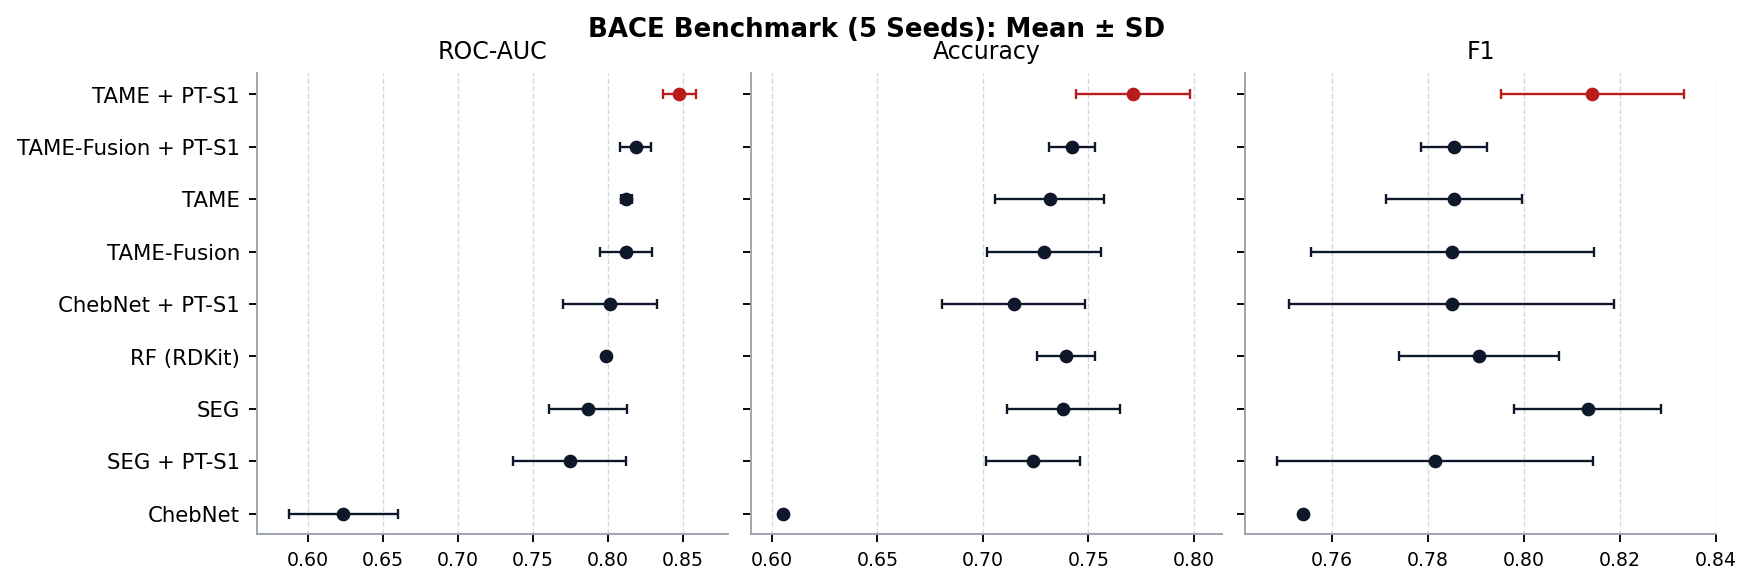

In [7]:
summary_df = results_df.groupby('model', as_index=False).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
    threshold_mean=('threshold', 'mean'),
    n_runs=('seed', 'nunique'),
)
summary_df = summary_df.sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)
summary_df

label_map = {
    'RF_RDKit': 'RF (RDKit)',
    'CHEBNET_VANILLA': 'ChebNet',
    'CHEBNET_PRETRAINED_STAGE1': 'ChebNet + PT-S1',
    'SEG_VANILLA': 'SEG',
    'SEG_PRETRAINED_STAGE1': 'SEG + PT-S1',
    'TAME_VANILLA': 'TAME',
    'TAME_PRETRAINED_STAGE1': 'TAME + PT-S1',
    'TAME_FUSION_VANILLA': 'TAME-Fusion',
    'TAME_FUSION_PRETRAINED_STAGE1': 'TAME-Fusion + PT-S1',
}
plot_df = summary_df.copy()
plot_df['label'] = plot_df['model'].map(label_map).fillna(plot_df['model'])

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 0.8,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 9,
})

y = np.arange(len(plot_df))
y_labels = plot_df['label'].tolist()

fig, axes = plt.subplots(
    1, 3, figsize=(10.2, 3.2), sharey=True, constrained_layout=True
)

metrics = [
    ('roc_auc_mean', 'roc_auc_std', 'ROC-AUC'),
    ('accuracy_mean', 'accuracy_std', 'Accuracy'),
    ('f1_mean', 'f1_std', 'F1'),
]

for ax, (m_col, s_col, title) in zip(axes, metrics):
    mu = plot_df[m_col].to_numpy(dtype=np.float32)
    sd = plot_df[s_col].fillna(0.0).to_numpy(dtype=np.float32)
    best_idx = int(np.argmax(mu))

    for i in range(len(mu)):
        c = '#0f172a' if i != best_idx else '#b91c1c'
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt='o', markersize=4.8,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.min(mu - sd))
    xmax = float(np.max(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.set_yticks(y, labels=y_labels)
    ax.grid(axis='x', color='#d1d5db', linestyle='--', linewidth=0.6, alpha=0.9)
    ax.grid(axis='y', visible=False)
    ax.invert_yaxis()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9ca3af')
    ax.spines['bottom'].set_color('#9ca3af')

fig.suptitle('BACE Benchmark (5 Seeds): Mean ± SD', y=1.03, fontsize=11, fontweight='bold')
plt.show()

In [8]:
results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

raw_path = results_dir / 'bace_full_benchmark_5seed_raw.csv'
summary_path = results_dir / 'bace_full_benchmark_5seed_summary.csv'
config_path = results_dir / 'bace_full_benchmark_5seed_config.json'

results_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)

config_payload = {
    'dataset': 'BACE',
    'task': 'classification',
    'splitter': 'deepchem_molnet_scaffold',
    'split_fractions': None,
    'split_seed': None,
    'seeds': SEEDS,
    'models': [
        'RF_RDKit',
        'CHEBNET_VANILLA',
        'CHEBNET_PRETRAINED_STAGE1',
        'SEG_VANILLA',
        'SEG_PRETRAINED_STAGE1',
        'TAME_VANILLA',
        'TAME_PRETRAINED_STAGE1',
        'TAME_FUSION_VANILLA',
        'TAME_FUSION_PRETRAINED_STAGE1',
    ],
}
pd.Series(config_payload).to_json(config_path, indent=2)

print(f'Saved raw results: {raw_path.resolve()}')
print(f'Saved summary: {summary_path.resolve()}')
print(f'Saved config: {config_path.resolve()}')


Saved raw results: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_full_benchmark_5seed_raw.csv
Saved summary: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_full_benchmark_5seed_summary.csv
Saved config: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\bace_full_benchmark_5seed_config.json


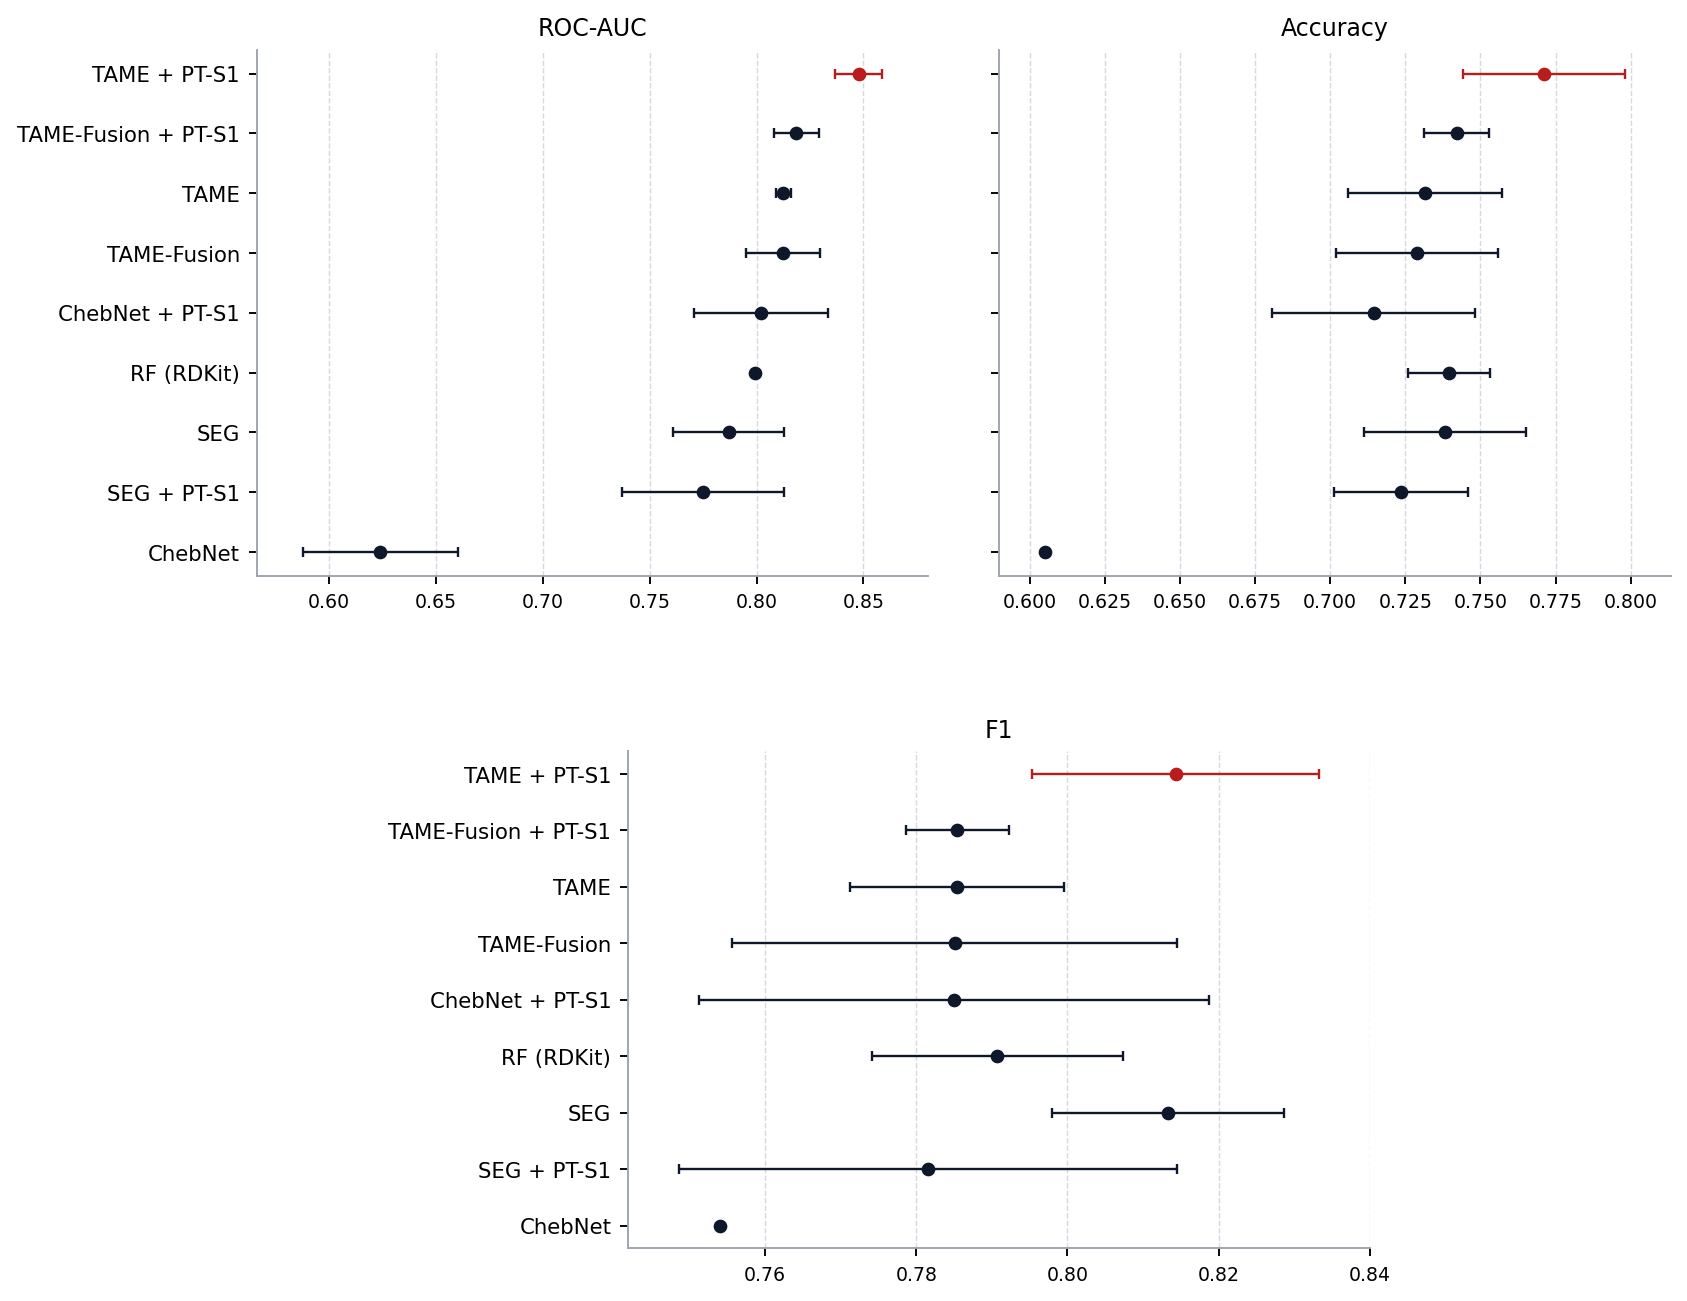

,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,f1_mean,f1_std,label
0,TAME_PRETRAINED_STAGE1,0.847681,0.011008,0.771053,0.026885,0.814300,0.018997,TAME + PT-S1
1,TAME_FUSION_PRETRAINED_STAGE1,0.818623,0.010560,0.742105,0.010810,0.785439,0.006825,TAME-Fusion + PT-S1
2,TAME_VANILLA,0.812500,0.003607,0.731579,0.025649,0.785437,0.014162,TAME
3,TAME_FUSION_VANILLA,0.812283,0.017299,0.728947,0.026885,0.785119,0.029429,TAME-Fusion
4,CHEBNET_PRETRAINED_STAGE1,0.801920,0.031348,0.714474,0.033739,0.784954,0.033758,ChebNet + PT-S1
5,RF_RDKit,0.799185,0.000847,0.739474,0.013642,0.790745,0.016657,RF (RDKit)
6,SEG_VANILLA,0.786884,0.026002,0.738158,0.026885,0.813343,0.015328,SEG
7,SEG_PRETRAINED_STAGE1,0.774819,0.037771,0.723684,0.022310,0.781552,0.032937,SEG + PT-S1
8,CHEBNET_VANILLA,0.623841,0.036211,0.605263,0.000000,0.754098,0.000000,ChebNet


In [2]:
# Reload saved BACE benchmark summary and re-plot in a 2-top / 1-centered-bottom layout.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'benchmarking').exists()), here)

results_dir = workspace_root / 'benchmarking' / 'results'
summary_path = results_dir / 'bace_full_benchmark_5seed_summary.csv'

if not summary_path.exists():
    raise FileNotFoundError(f'Summary file not found: {summary_path}')

def load_column(csv_path, column_name):
    return pd.read_csv(csv_path, usecols=[column_name])[column_name]

# Load every required column individually.
summary_plot_df_reload = pd.DataFrame({
    'model': load_column(summary_path, 'model'),
    'roc_auc_mean': load_column(summary_path, 'roc_auc_mean'),
    'roc_auc_std': load_column(summary_path, 'roc_auc_std'),
    'accuracy_mean': load_column(summary_path, 'accuracy_mean'),
    'accuracy_std': load_column(summary_path, 'accuracy_std'),
    'f1_mean': load_column(summary_path, 'f1_mean'),
    'f1_std': load_column(summary_path, 'f1_std'),
})

# Classification: higher is better.
# Stepwise deterministic ranking (least important tie-break first, primary metric last).
summary_plot_df_reload = summary_plot_df_reload.sort_values(
    'f1_mean', ascending=False, kind='mergesort'
).reset_index(drop=True)
summary_plot_df_reload = summary_plot_df_reload.sort_values(
    'accuracy_mean', ascending=False, kind='mergesort'
).reset_index(drop=True)
summary_plot_df_reload = summary_plot_df_reload.sort_values(
    'roc_auc_mean', ascending=False, kind='mergesort'
).reset_index(drop=True)

label_map_reload = {
    'RF_RDKit': 'RF (RDKit)',
    'CHEBNET_VANILLA': 'ChebNet',
    'CHEBNET_PRETRAINED_STAGE1': 'ChebNet + PT-S1',
    'SEG_VANILLA': 'SEG',
    'SEG_PRETRAINED_STAGE1': 'SEG + PT-S1',
    'TAME_VANILLA': 'TAME',
    'TAME_PRETRAINED_STAGE1': 'TAME + PT-S1',
    'TAME_FUSION_VANILLA': 'TAME-Fusion',
    'TAME_FUSION_PRETRAINED_STAGE1': 'TAME-Fusion + PT-S1',
}
summary_plot_df_reload['label'] = summary_plot_df_reload['model'].map(label_map_reload).fillna(summary_plot_df_reload['model'])

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 0.8,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 9,
})

y = np.arange(len(summary_plot_df_reload))
y_labels = summary_plot_df_reload['label'].tolist()

fig = plt.figure(figsize=(10.4, 8.6))
ax_roc = fig.add_axes([0.08, 0.56, 0.38, 0.36])
ax_acc = fig.add_axes([0.50, 0.56, 0.38, 0.36], sharey=ax_roc)
ax_f1 = fig.add_axes([0.29, 0.10, 0.42, 0.34])

axes = [ax_roc, ax_acc, ax_f1]
metrics_reload = [
    ('roc_auc_mean', 'roc_auc_std', 'ROC-AUC'),
    ('accuracy_mean', 'accuracy_std', 'Accuracy'),
    ('f1_mean', 'f1_std', 'F1'),
]

for ax, (m_col, s_col, title) in zip(axes, metrics_reload):
    mu = summary_plot_df_reload[m_col].to_numpy(dtype=np.float32)
    sd = summary_plot_df_reload[s_col].fillna(0.0).to_numpy(dtype=np.float32)

    best_idx = int(np.argmax(mu))

    for i in range(len(mu)):
        c = '#0f172a' if i != best_idx else '#b91c1c'
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt='o', markersize=4.8,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.min(mu - sd))
    xmax = float(np.max(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.grid(axis='x', color='#d1d5db', linestyle='--', linewidth=0.6, alpha=0.9)
    ax.grid(axis='y', visible=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9ca3af')
    ax.spines['bottom'].set_color('#9ca3af')

# Invert only once per independent y-axis (avoid double inversion on shared y).
ax_roc.invert_yaxis()
ax_f1.invert_yaxis()

ax_roc.set_yticks(y, labels=y_labels)
ax_acc.tick_params(axis='y', labelleft=False)
ax_f1.set_yticks(y, labels=y_labels)
ax_acc.set_ylim(ax_roc.get_ylim())

plt.show()

summary_plot_df_reload